# **MÓDULO Final - Diagnóstico de Hipertireoidismo **

In [444]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Carrega a base de dados, verifique os tipos de dados e os dados faltantes.


As variáveis Sex e binaryClass foram convertidas de categóricas para numéricas. A coluna referral source é renomeada para referral_source. As colunas age, TSH, T3, TT4, T4U e FTI têm seus tipos alterados de object para float, enquanto referral_source passa de object para string. Quanto aos valores nulos, linhas com até 5% de ausência são removidas. Para colunas com entre 5% e 30% de valores nulos, é aplicado o preenchimento pela mediana. Já colunas com mais de 30% de dados ausentes são excluídas do conjunto de dados.

In [345]:

# Carregando a Base de dados
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv', delimiter=',')
df

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3767,30,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,f,?,other,P
3768,68,F,f,f,f,f,f,f,f,f,...,t,124,t,1.08,t,114,f,?,SVI,P
3769,74,F,f,f,f,f,f,f,f,f,...,t,112,t,1.07,t,105,f,?,other,P
3770,72,M,f,f,f,f,f,f,f,f,...,t,82,t,0.94,t,87,f,?,SVI,P


In [346]:
# Aplicando o map para alterar o tipo de gênero 
df['sex'] = df['sex'].map({
    'M': 0,
    'F': 1
})

In [347]:
# Aplicando a função map, a variável binaryClass será convertida de multiclasse para binária.
df['binaryClass'] = df['binaryClass'].map({
    'N': 0, # não tem hipertireoide 
    'P': 1 # tem hipertireoide
})

In [348]:
# Aplicando o replace para alterar os dados true , false e nulos para que o dataframe reconheça como números.
df = df.replace({
    'F': 0,
    'f': 0,
    'T': 1,
    't': 1,
    '?': np.nan
})

C:\Users\User\AppData\Local\Temp\ipykernel_4148\1346707458.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


In [349]:
# Renomeando a coluna 
df = df.rename(columns={'referral source': 'referral_source'})

In [350]:
df.dtypes

age                           object
sex                          float64
on thyroxine                   int64
query on thyroxine             int64
on antithyroid medication      int64
sick                           int64
pregnant                       int64
thyroid surgery                int64
I131 treatment                 int64
query hypothyroid              int64
query hyperthyroid             int64
lithium                        int64
goitre                         int64
tumor                          int64
hypopituitary                  int64
psych                          int64
TSH measured                   int64
TSH                           object
T3 measured                    int64
T3                            object
TT4 measured                   int64
TT4                           object
T4U measured                   int64
T4U                           object
FTI measured                   int64
FTI                           object
TBG measured                   int64
T

In [351]:
# Transformando o tipo das colunas em números
cols = ['age', 'TSH', 'T3', 'TT4','T4U', 'FTI' ]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Transformando o tipo da coluna em str
df['referral_source'] = df['referral_source'].astype('string')

In [352]:
# Verificando as colunas que tem nulos
(df.isnull().sum()/len(df)) * 100

age                            0.026511
sex                            3.976670
on thyroxine                   0.000000
query on thyroxine             0.000000
on antithyroid medication      0.000000
sick                           0.000000
pregnant                       0.000000
thyroid surgery                0.000000
I131 treatment                 0.000000
query hypothyroid              0.000000
query hyperthyroid             0.000000
lithium                        0.000000
goitre                         0.000000
tumor                          0.000000
hypopituitary                  0.000000
psych                          0.000000
TSH measured                   0.000000
TSH                            9.782609
T3 measured                    0.000000
T3                            20.387063
TT4 measured                   0.000000
TT4                            6.124072
T4U measured                   0.000000
T4U                           10.259809
FTI measured                   0.000000


In [353]:
# Para os nulos com valores ate 5% dos dados foi feito a remoção das linhas.
df = df.dropna(subset=['age', 'sex'])

# Para os nulos com o valores maiores de 5% e menores que 30% - foram feitos a substituição dos dados pela médiana.
df['TSH'] = df['TSH'].fillna(df['TSH'].median())
df['T3'] = df['T3'].fillna(df['T3'].median())
df['TT4'] = df['TT4'].fillna(df['TT4'].median())
df['T4U'] = df['T4U'].fillna(df['T4U'].median())
df['FTI'] = df['FTI'].fillna(df['FTI'].median())

# Para os nulos com valores maiores que 30% , a coluna foi excluída.
df = df.drop(columns=['TBG'])

In [354]:
# Verificando as colunas que tem nulos
(df.isnull().sum()/len(df)) * 100

age                          0.0
sex                          0.0
on thyroxine                 0.0
query on thyroxine           0.0
on antithyroid medication    0.0
sick                         0.0
pregnant                     0.0
thyroid surgery              0.0
I131 treatment               0.0
query hypothyroid            0.0
query hyperthyroid           0.0
lithium                      0.0
goitre                       0.0
tumor                        0.0
hypopituitary                0.0
psych                        0.0
TSH measured                 0.0
TSH                          0.0
T3 measured                  0.0
T3                           0.0
TT4 measured                 0.0
TT4                          0.0
T4U measured                 0.0
T4U                          0.0
FTI measured                 0.0
FTI                          0.0
TBG measured                 0.0
referral_source              0.0
binaryClass                  0.0
dtype: float64

In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3621 entries, 0 to 3771
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3621 non-null   float64
 1   sex                        3621 non-null   float64
 2   on thyroxine               3621 non-null   int64  
 3   query on thyroxine         3621 non-null   int64  
 4   on antithyroid medication  3621 non-null   int64  
 5   sick                       3621 non-null   int64  
 6   pregnant                   3621 non-null   int64  
 7   thyroid surgery            3621 non-null   int64  
 8   I131 treatment             3621 non-null   int64  
 9   query hypothyroid          3621 non-null   int64  
 10  query hyperthyroid         3621 non-null   int64  
 11  lithium                    3621 non-null   int64  
 12  goitre                     3621 non-null   int64  
 13  tumor                      3621 non-null   int64  
 1

# 2. Analise de outliers.

Foi identificada a presença de possíveis outliers em quatro colunas: age, T3, TT4 e FTI.
Na coluna age, foi aplicado o método do IQR para definir os limites inferior e superior, permitindo a remoção dos valores discrepantes. Na coluna Triiodotironina (T3), também foi utilizado o IQR. No entanto, os limites encontrados estavam fora do esperado clinicamente. Por isso, foram considerados valores de referência reais para o exame de T3, com a aplicação de uma margem de tolerância. Com esse critério, foram removidos menos de 1% dos dados. Para a coluna Tiroxina total (TT4), o IQR indicou um limite superior que abrangia cerca de 5% dos dados. Assim, foi realizada uma análise com base em valores clínicos reais, aplicando uma margem para ajuste. Aproximadamente 3% dos dados foram removidos. Na coluna FTI, o método IQR indicou necessidade de ajuste apenas no limite superior. Utilizando valores de referência clínica, foram removidos cerca de 0,66% dos dados.
Em todos os casos, os valores de referência utilizados foram obtidos do site MD.Saúde, garantindo maior coerência clínica no tratamento dos dados.

In [356]:
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,binaryClass
count,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,...,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.000000,3621.0,3621.000000
mean,51.840099,0.684618,0.123723,0.013532,0.011875,0.039492,0.014085,0.014361,0.014913,0.063242,...,0.794256,2.008600,0.940072,107.889202,0.898647,0.993992,0.899199,109.933195,0.0,0.922673
std,20.094311,0.464732,0.329310,0.115554,0.108339,0.194789,0.117856,0.118989,0.121222,0.243432,...,0.404300,0.738879,0.237387,34.547404,0.301838,0.185271,0.301106,31.177883,0.0,0.267146
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.050000,0.000000,2.000000,0.000000,0.250000,0.000000,2.000000,0.0,0.000000
25%,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.700000,1.000000,89.000000,1.000000,0.890000,1.000000,94.000000,0.0,1.000000
50%,54.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,1.000000,103.000000,1.000000,0.980000,1.000000,107.000000,0.0,1.000000
75%,67.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.200000,1.000000,123.000000,1.000000,1.070000,1.000000,122.000000,0.0,1.000000
max,455.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,10.600000,1.000000,430.000000,1.000000,2.320000,1.000000,395.000000,0.0,1.000000


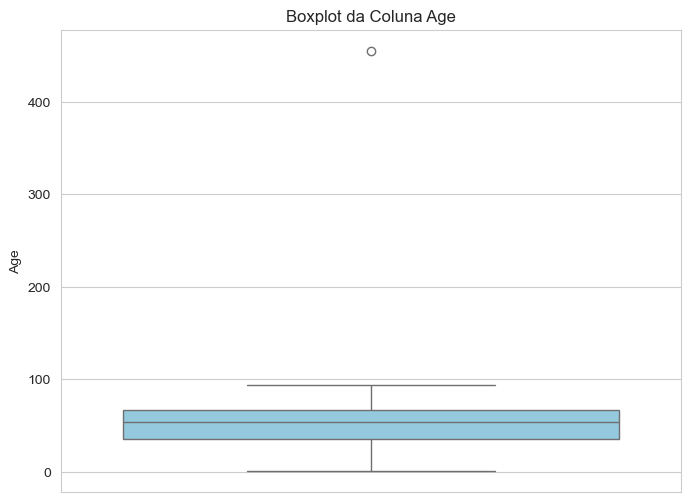

In [357]:
# Gráfico Boxplot coluna Age
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='age', color= 'skyblue')
plt.title('Boxplot da Coluna Age')
plt.ylabel('Age')
plt.show()

In [358]:
# IQR Coluna Age
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

limite_superior_age = Q3_age + 1.5 * IQR_age
limite_inferior_age = Q1_age - 1.5 * IQR_age

In [359]:
(df['age'] > limite_superior_age ).mean() * 100

np.float64(0.027616680475006903)

In [360]:
# Alterando os valores da coluna Age utilizando o IQR
df = df[(df['age'] >= limite_inferior_age) & 
        (df['age'] <= limite_superior_age)]

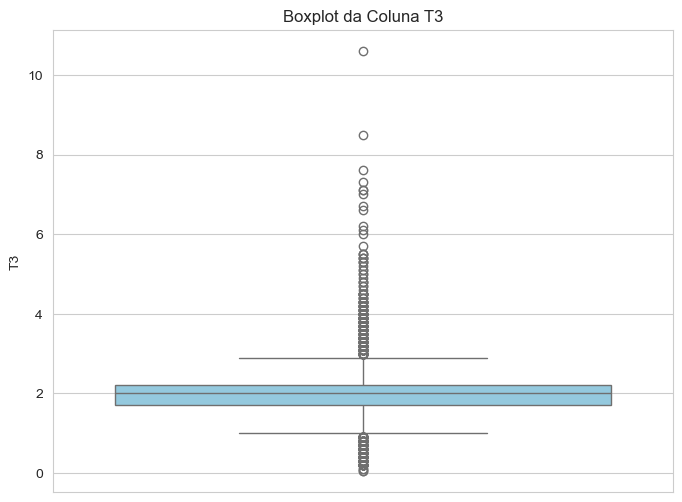

In [361]:
# Gráfico Boxplot coluna T3
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='T3', color= 'skyblue')
plt.title('Boxplot da Coluna T3')
plt.ylabel('T3')
plt.show()

In [362]:
# IQR Coluna T3
Q1_T3 = df['T3'].quantile(0.25)
Q3_T3 = df['T3'].quantile(0.75)

IQR_T3 = Q3_T3 - Q1_T3

limite_superior_T3 = Q3_T3 + 1.5 * IQR_T3
limite_inferior_T3 = Q1_T3 - 1.5 * IQR_T3

In [363]:
limite_inferior_T3

np.float64(0.9499999999999996)

In [364]:
limite_superior_T3

np.float64(2.9500000000000006)

In [365]:
(df['T3'] < 0.30 ).mean() * 100

np.float64(0.6077348066298343)

In [366]:
(df['T3'] > 6 ).mean() * 100

np.float64(0.30386740331491713)

In [367]:
# Limitando os valores da coluna T3 
df = df[(df['T3'] >= 0.3) & (df['T3'] <= 6)]

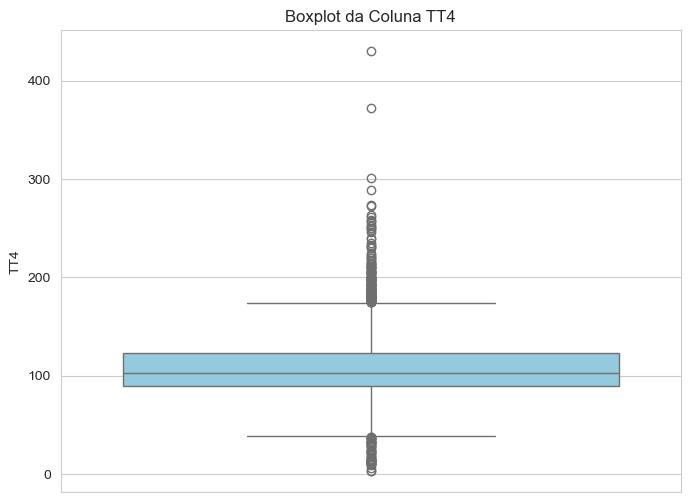

In [368]:
# Gráfico Boxplot coluna TT4
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='TT4', color= 'skyblue')
plt.title('Boxplot da Coluna TT4')
plt.ylabel('TT4')
plt.show()

In [369]:
# IQR Coluna TT4
Q1_TT4 = df['TT4'].quantile(0.25)
Q3_TT4 = df['TT4'].quantile(0.75)

IQR_TT4 = Q3_TT4 - Q1_TT4

limite_superior_TT4 = Q3_TT4 + 1.5 * IQR_TT4
limite_inferior_TT4 = Q1_TT4 - 1.5 * IQR_TT4

In [370]:
limite_inferior_TT4 #20

np.float64(38.0)

In [371]:
(df['TT4'] < limite_inferior_TT4).mean() * 100

np.float64(1.4218009478672986)

In [372]:
limite_superior_TT4

np.float64(174.0)

In [373]:
(df['TT4'] > 200 ).mean() * 100

np.float64(1.5054362977418456)

In [374]:
# Limitando os valores da coluna TT4
df = df[(df['TT4'] >= limite_inferior_TT4 ) & (df['TT4'] <= 200 )]
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,binaryClass
count,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,...,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.000000,3482.0,3482.000000
mean,51.820505,0.680930,0.121769,0.013785,0.011488,0.040781,0.012349,0.014072,0.014934,0.062033,...,0.788914,1.994899,0.937679,107.190121,0.896898,0.989493,0.897473,109.602527,0.0,0.934808
std,18.955631,0.466183,0.327066,0.116615,0.106578,0.197811,0.110455,0.117806,0.121306,0.241251,...,0.408138,0.609963,0.241771,27.491975,0.304135,0.174419,0.303384,25.445120,0.0,0.246901
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.300000,0.000000,38.000000,0.000000,0.250000,0.000000,33.000000,0.0,0.000000
25%,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.700000,1.000000,89.000000,1.000000,0.890000,1.000000,95.000000,0.0,1.000000
50%,54.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,1.000000,103.000000,1.000000,0.980000,1.000000,107.000000,0.0,1.000000
75%,67.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.200000,1.000000,122.000000,1.000000,1.060000,1.000000,121.000000,0.0,1.000000
max,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.500000,1.000000,200.000000,1.000000,2.010000,1.000000,265.000000,0.0,1.000000


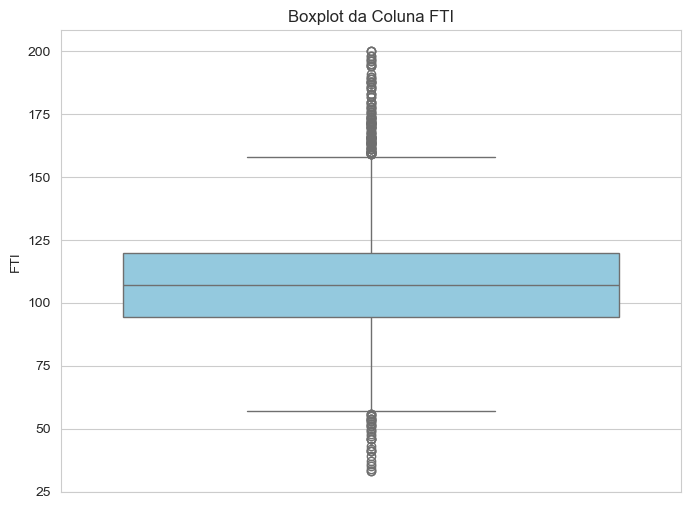

In [375]:
# Gráfico Boxplot coluna FTI
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df_alterado, y='FTI', color= 'skyblue')
plt.title('Boxplot da Coluna FTI')
plt.ylabel('FTI')
plt.show()

In [376]:
# IQR Coluna FTI
Q1_FTI = df['FTI'].quantile(0.25)
Q3_FTI = df['FTI'].quantile(0.75)

IQR_FTI = Q3_FTI - Q1_FTI

limite_superior_FTI = Q3_FTI + 1.5 * IQR_FTI
limite_inferior_FTI = Q1_FTI - 1.5 * IQR_FTI

In [377]:
limite_inferior_FTI

np.float64(56.0)

In [378]:
limite_superior_FTI

np.float64(160.0)

In [379]:
(df['FTI'] > limite_superior_FTI).mean() * 100

np.float64(4.135554279149914)

In [380]:
(df['FTI'] > 200).mean() * 100

np.float64(0.6605399195864445)

In [381]:
# Limitando os valores da coluna FTI
df = df[( df['FTI'] <= 200.0 )]

# 3. Análise Univariada e Bivariada

Observou-se que mais de 80% dos registros do dataset correspondem a casos positivos relacionados a distúrbios da tireoide. Em relação ao perfil dos pacientes, aproximadamente 70% são do sexo feminino, indicando uma maior incidência nesse grupo. Além disso, cerca de 1% dos pacientes apresentaram indicação de cirurgia na tireoide, possivelmente associada a casos mais graves, como nódulos ou câncer. Por fim, verificou-se que alterações nos níveis de Triiodotironina (T3), Tiroxina total (TT4) e FTI estão frequentemente associadas a pacientes com disfunções da tireoide, reforçando a relevância dessas variáveis para a análise e modelagem dos dados.

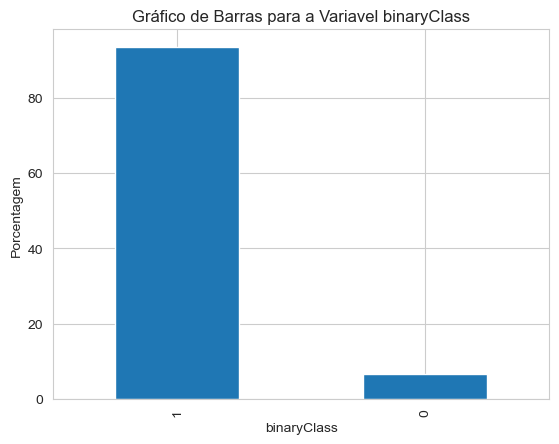

In [382]:
#contagem da coluna binaryClass
contagem_binaryClass = df['binaryClass'].value_counts()

porcentagem_binaryClass = (contagem_binaryClass/ contagem_binaryClass.sum()) * 100
ax = porcentagem_binaryClass.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel binaryClass')
plt.xlabel('binaryClass')
plt.ylabel('Porcentagem')
plt.show()

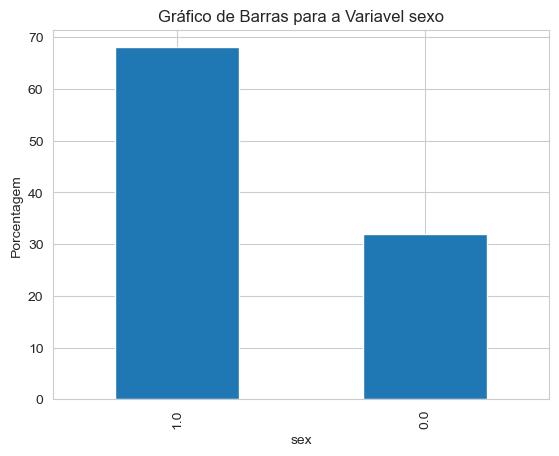

In [383]:
#contagem da coluna sex
contagem_sex = df['sex'].value_counts()

porcentagem_sex = (contagem_sex/ contagem_sex.sum()) * 100
ax = porcentagem_sex.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel sexo')
plt.xlabel('sex')
plt.ylabel('Porcentagem')
plt.show()

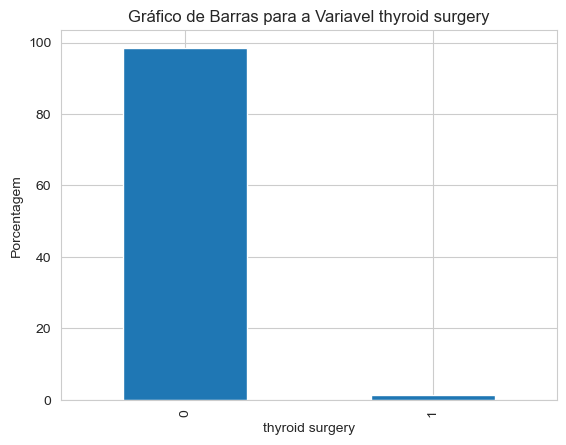

In [384]:
#contagem da coluna thyroid_surgery 
contagem_thyroid_surgery = df['thyroid surgery'].value_counts()

porcentagem_thyroid_surgery = (contagem_thyroid_surgery/ contagem_thyroid_surgery.sum()) * 100
ax = porcentagem_thyroid_surgery.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel thyroid surgery')
plt.xlabel('thyroid surgery')
plt.ylabel('Porcentagem')
plt.show()

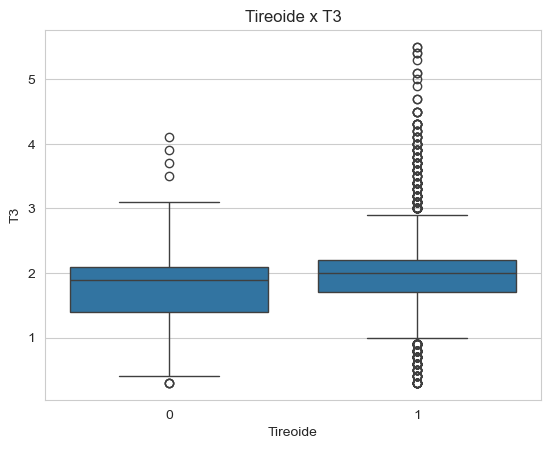

In [385]:
# Gráfico de Tireoide x T3
sns.boxplot(x='binaryClass', y='T3', data=df)
plt.title('Tireoide x T3')
plt.xlabel('Tireoide')
plt.ylabel('T3')
plt.show()

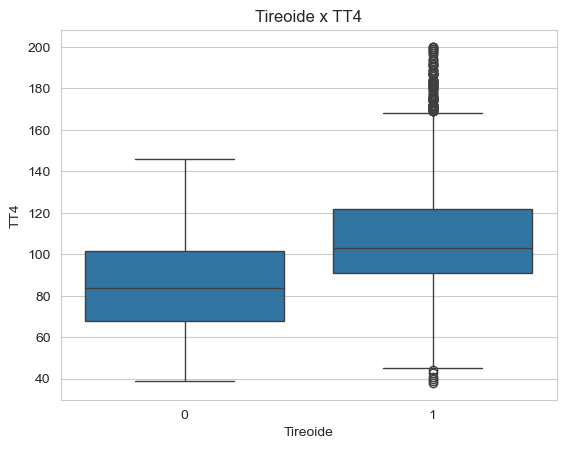

In [386]:
# Gráfico de Tireoide x TT4
sns.boxplot(x='binaryClass', y='TT4', data=df)
plt.title('Tireoide x TT4')
plt.xlabel('Tireoide')
plt.ylabel('TT4')
plt.show()

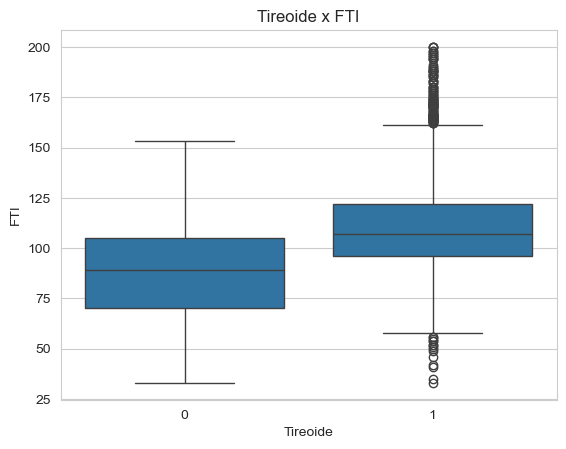

In [387]:
# Gráfico de Tireoide x FTI
sns.boxplot(x='binaryClass', y='FTI', data=df)
plt.title('Tireoide x FTI')
plt.xlabel('Tireoide')
plt.ylabel('FTI')
plt.show()

# 4. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

Foram removidas as colunas 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured' e 'referral_source', pois essas variáveis apenas indicam a realização dos exames e a origem do encaminhamento dos pacientes, não contribuindo de forma relevante para a análise dos dados nem para o desempenho do modelo.
As variáveis que apresentaram maior correlação com a variável alvo foram TSH (0,41), FTI (0,25) e Tiroxina total (TT4) (0,21), indicando que essas possuem maior relevância na predição do modelo.

In [388]:
df = df.drop(columns=['T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured','referral_source'])

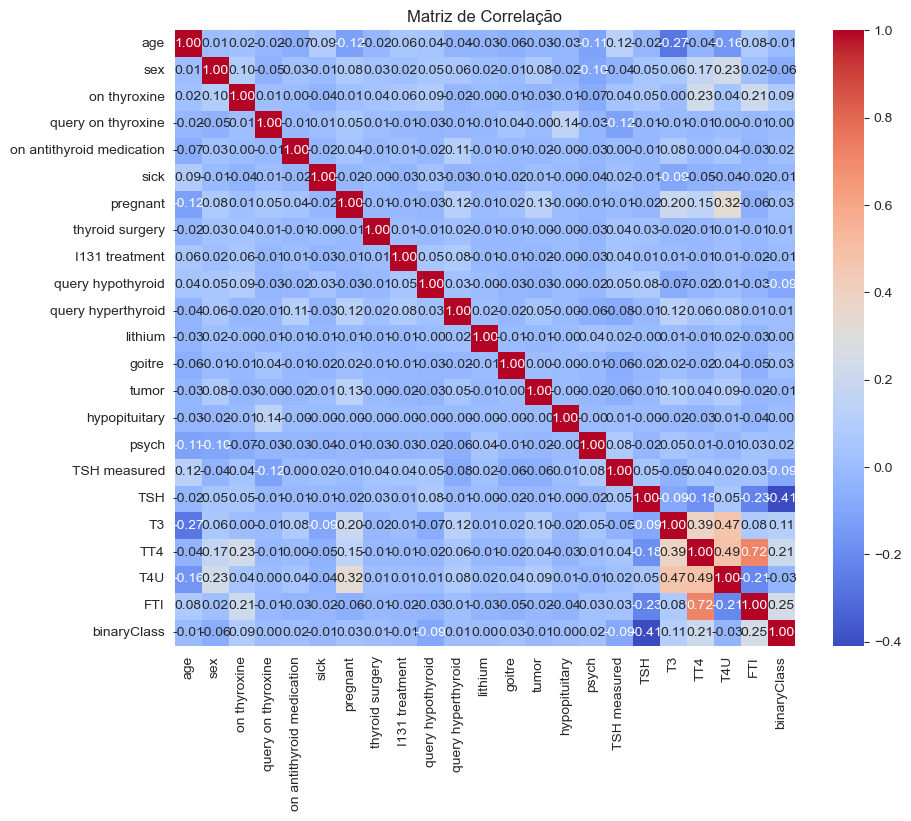

In [389]:
# Matriz de correlação
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 5. Faça a separação da base em X e Y e em seguida nas bases de treino e teste. Tambem faça a padronização dos dados. 

In [390]:
# Separando as bases X e Y
X = df.drop(columns=['binaryClass'])
Y = df['binaryClass']

In [391]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [392]:
# Padronizando os Dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Coloque Hiperparametros e Treine o modelo SVM com sua base de treino.

In [432]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC())
])

In [435]:
# Colocando hiperparametros

param_grid_svm = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [1, 10, 20, 50, 100],
    'svm__gamma': [ 'auto', 0.1, 0.01, 0.001]
}
grid_search_svm = GridSearchCV( pipeline,
                           param_grid=param_grid_svm,
                           scoring='f1', 
                           cv=5, 
                           verbose=2, 
                           n_jobs=-1)


grid_search_svm.fit(X_train_scaled_balanced, Y_train_balanced)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [1, 10, ...], 'svm__gamma': ['auto', 0.1, ...], 'svm__kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [436]:
best_params = grid_search_svm.best_params_
best_svm_model = grid_search_svm.best_estimator_

In [438]:
print("Melhores hiperparâmetros encontrados:", best_params)

Melhores hiperparâmetros encontrados: {'svm__C': 20, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}


In [437]:
Y_train_pred = best_svm_model.predict(X_train_scaled_balanced)

In [439]:
relatorio = classification_report(Y_train_balanced, Y_train_pred)
print("Relatório de Classificação com o Melhor Modelo:")
print(relatorio)

Relatório de Classificação com o Melhor Modelo:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2595
           1       1.00      1.00      1.00      2595

    accuracy                           1.00      5190
   macro avg       1.00      1.00      1.00      5190
weighted avg       1.00      1.00      1.00      5190



In [440]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_train_balanced, Y_train_pred))

[[2595    0]
 [   4 2591]]


# 7. Realize as previsões para a base de teste e traga a avaliação.

O modelo teve um desempenho quase perfeito nos dados de treino e também apresentou bons resultados nos dados de teste, com poucos erros, mostrando que consegue generalizar bem e fazer boas previsões.

In [441]:
Y_pred = best_svm_model.predict(X_test_scaled)

In [442]:
#SEU CÓDIGO AQUI
relatorio = classification_report(Y_test, Y_pred)
print("Relatório de Classificação com o Melhor Modelo:")
print(relatorio)

Relatório de Classificação com o Melhor Modelo:
              precision    recall  f1-score   support

           0       0.85      0.75      0.80        55
           1       0.98      0.99      0.98       637

    accuracy                           0.97       692
   macro avg       0.92      0.87      0.89       692
weighted avg       0.97      0.97      0.97       692



In [443]:
print(confusion_matrix(Y_test, Y_pred))

[[ 41  14]
 [  7 630]]


# 8. Treine o modelo Random Forest com sua base de treino + realize as previsões e avalições.

O modelo Random Forest teve um ótimo desempenho nos dados de teste, com acurácia próxima de 100%. Ele apresentou apenas 1 falso negativo e 2 falsos positivos, mostrando que quase não erra. O recall para a classe de doentes foi de aproximadamente 99,8%, indicando que o modelo identifica quase todos os pacientes com a doença. Além disso, também teve bom desempenho na identificação de pessoas saudáveis, mesmo com os dados desbalanceados.

In [458]:
rf_model = RandomForestClassifier(random_state=42,
    class_weight='balanced')

In [459]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [460]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='f1')


In [461]:
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,100
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [464]:
best_params_random = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params_random}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}


In [465]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [466]:
# Fazendo previsões no conjunto de teste
Y_pred = best_rf_model.predict(X_test)

In [467]:
# Avaliando o modelo Random Forest
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação Random Forest:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 1.00
Relatório de Classificação Random Forest:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        55
           1       1.00      1.00      1.00       637

    accuracy                           1.00       692
   macro avg       0.99      0.98      0.99       692
weighted avg       1.00      1.00      1.00       692

Matriz de Confusão:
 [[ 53   2]
 [  1 636]]


# 9. Qual modelo se saiu melhor? O SVM ou Random Forest?

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho, com apenas 1 falso negativo e 2 falsos positivos, enquanto o SVM apresentou 7 falsos negativos e 14 falsos positivos. Além disso, o Random Forest atingiu um recall de aproximadamente 99,8% para a classe de doentes e cerca de 96% para a classe de saudáveis, demonstrando maior capacidade de generalização e um melhor equilíbrio entre as métricas de avaliação.